In [ ]:


import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("GPU Available:", torch.cuda.is_available())

dataset_path = "/kaggle/input/garbage-trashbox-hybrid-dataset"

classes = ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']

def create_file_paths_dataset():
    data = []
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            for filename in os.listdir(class_path):
                data.append({
                    'file_path': os.path.join(class_path, filename),
                    'class_name': class_name,
                    'class_idx': class_idx
                })
    return pd.DataFrame(data)

df = create_file_paths_dataset()

print("\nClass distribution:")
print(df['class_name'].value_counts())

def create_stratified_split(df, train_size=0.7, val_size=0.15, test_size=0.15):
    train_df, temp_df = train_test_split(
        df, 
        test_size=(val_size + test_size), 
        stratify=df['class_name'], 
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=test_size/(val_size + test_size), 
        stratify=temp_df['class_name'], 
        random_state=42
    )
    return train_df, val_df, test_df

train_df, val_df, test_df = create_stratified_split(df)

print(f"\nTraining set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

class HybridWasteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        try:
            image = Image.open(row['file_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='black')
        if self.transform:
            image = self.transform(image)
        return image, row['class_idx']

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = HybridWasteDataset(train_df, transform=train_transform)
val_dataset = HybridWasteDataset(val_df, transform=val_test_transform)
test_dataset = HybridWasteDataset(test_df, transform=val_test_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("\nSample batch loaded:")
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Unique labels in batch: {torch.unique(labels).tolist()}")

print("\n✓ Phase 1 Complete - Ready for Phase 2 (Model Architecture)")


GPU Available: True

Class distribution:
class_name
cardboard    4000
clothes      4000
glass        4000
metal        4000
paper        4000
plastic      4000
Name: count, dtype: int64

Training set: 16800 images
Validation set: 3600 images
Test set: 3600 images

Sample batch loaded:
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Unique labels in batch: [0, 1, 2, 3, 4, 5]

✓ Phase 1 Complete - Ready for Phase 2 (Model Architecture)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class HybridWasteClassifier(nn.Module):
    def __init__(self, num_classes=6, dropout_rate=0.5, freeze_backbones=True):
        super(HybridWasteClassifier, self).__init__()
        
        self.densenet = models.densenet121(weights='IMAGENET1K_V1')
        self.efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
        
        self.densenet_features = self.densenet.features
        self.efficientnet_features = self.efficientnet.features
        
        if freeze_backbones:
            for param in self.densenet_features.parameters():
                param.requires_grad = False
            for param in self.efficientnet_features.parameters():
                param.requires_grad = False
        
        densenet_feature_dim = 1024   
        efficientnet_feature_dim = 1280  
        
        self.fusion_dim = densenet_feature_dim + efficientnet_feature_dim  # 2304
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.fusion_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate/2),
            nn.Linear(256, num_classes)
        )
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        densenet_features = self.densenet_features(x) 
        
        efficientnet_features = self.efficientnet_features(x) 
        if densenet_features.shape[2:] != efficientnet_features.shape[2:]:
            efficientnet_features = F.adaptive_avg_pool2d(
                efficientnet_features, densenet_features.shape[2:]
            )
        
        fused_features = torch.cat([densenet_features, efficientnet_features], dim=1)  # [batch, 2304, 7, 7]
        
        output = self.classifier(fused_features)
        
        return output

model = HybridWasteClassifier(num_classes=6, freeze_backbones=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model created and moved to: {device}")

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

sample_input = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    output = model(sample_input)
    print(f"Model output shape: {output.shape}")
    print(f"Output sample: {output[0].cpu().numpy()}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                              lr=0.001, weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print("✓ Hybrid model architecture ready with frozen backbones")
print("✓ Loss function and optimizer configured")


Model created and moved to: cuda
Total parameters: 14,580,434
Trainable parameters: 3,619,030
Model output shape: torch.Size([2, 6])
Output sample: [-1.9143782  -0.43062025  2.3402975  -0.27960548  0.05112922 -0.21878615]
✓ Hybrid model architecture ready with frozen backbones
✓ Loss function and optimizer configured


In [ ]:
import time
from tqdm import tqdm
import torch

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

num_epochs = 10
best_val_acc = 0.0
patience = 5
patience_counter = 0

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

print("🚀 Starting training...")
print(f"Device: {device}")
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

for epoch in range(num_epochs):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    epoch_time = time.time() - start_time
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}] - {epoch_time:.1f}s')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%')
    print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies
        }, '/kaggle/working/best_hybrid_model.pth')
        print(f'✅ New best model saved! Val Acc: {val_acc:.2f}%')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'\n⏹ Early stopping triggered at epoch {epoch + 1}')
        print(f'Best validation accuracy: {best_val_acc:.2f}%')
        break
    
    print('-' * 60)

print("\n🎯 Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

checkpoint = torch.load('/kaggle/working/best_hybrid_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print("✓ Best model loaded for evaluation")


🚀 Starting training...
Device: cuda
Epochs: 10
Batch size: 32
Learning rate: 0.001



Epoch [1/10] - 246.2s
Train Loss: 0.8577, Train Acc: 68.12%
Val Loss:   0.4422, Val Acc:   85.58%
LR: 0.001000
✅ New best model saved! Val Acc: 85.58%
------------------------------------------------------------



Epoch [2/10] - 189.4s
Train Loss: 0.6501, Train Acc: 76.33%
Val Loss:   0.3892, Val Acc:   86.67%
LR: 0.001000
✅ New best model saved! Val Acc: 86.67%
------------------------------------------------------------



Epoch [3/10] - 194.2s
Train Loss: 0.5895, Train Acc: 78.54%
Val Loss:   0.3378, Val Acc:   88.50%
LR: 0.001000
✅ New best model saved! Val Acc: 88.50%
------------------------------------------------------------



Epoch [4/10] - 190.2s
Train Loss: 0.5589, Train Acc: 80.15%
Val Loss:   0.3134, Val Acc:   89.11%
LR: 0.001000
✅ New best model saved! Val Acc: 89.11%
------------------------------------------------------------


...


Epoch [6/10] - 198.7s
Train Loss: 0.5206, Train Acc: 81.54%
Val Loss:   0.3152, Val Acc:   88.81%
LR: 0.001000
------------------------------------------------------------



Epoch [7/10] - 200.1s
Train Loss: 0.5086, Train Acc: 81.85%
Val Loss:   0.2936, Val Acc:   89.75%
LR: 0.001000
✅ New best model saved! Val Acc: 89.75%
------------------------------------------------------------



Epoch [8/10] - 192.4s
Train Loss: 0.4878, Train Acc: 82.26%
Val Loss:   0.2979, Val Acc:   90.03%
LR: 0.001000
✅ New best model saved! Val Acc: 90.03%
------------------------------------------------------------



Epoch [9/10] - 188.6s
Train Loss: 0.4960, Train Acc: 82.79%
Val Loss:   0.2862, Val Acc:   90.28%
LR: 0.001000
✅ New best model saved! Val Acc: 90.28%
------------------------------------------------------------



Epoch [10/10] - 196.2s
Train Loss: 0.4709, Train Acc: 83.28%
Val Loss:   0.2779, Val Acc:   90.69%
LR: 0.001000
✅ New best model saved! Val Acc: 90.69%
------------------------------------------------------------

🎯 Training completed!
Best validation accuracy: 90.69%
✓ Best model loaded for evaluation


In [ ]:

import torch
import time
from tqdm import tqdm

checkpoint = torch.load('/kaggle/working/best_hybrid_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

best_val_acc = checkpoint['best_val_acc']
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']

print(f"Resuming training... Best val acc so far: {best_val_acc:.2f}%")


num_epochs = 20  
start_epoch = checkpoint['epoch']
patience = 7
patience_counter = 0


for epoch in range(start_epoch, num_epochs):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch [{epoch+1}/{num_epochs}] - {epoch_time:.1f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies
        }, '/kaggle/working/best_hybrid_model.pth')
        print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"\n⏹ Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        break
    
    print("-" * 60)

print("🎯 Extended training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")


Resuming training... Best val acc so far: 92.03%



Epoch [19/20] - 189.3s
Train Loss: 0.4128, Train Acc: 85.61%
Val Loss:   0.2524, Val Acc:   91.31%
LR: 0.001000
------------------------------------------------------------



Epoch [20/20] - 189.0s
Train Loss: 0.4133, Train Acc: 85.70%
Val Loss:   0.2486, Val Acc:   91.39%
LR: 0.001000
------------------------------------------------------------
🎯 Extended training completed!
Best validation accuracy: 92.03%


In [ ]:


checkpoint = torch.load('/kaggle/working/best_hybrid_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

best_val_acc = checkpoint['best_val_acc']
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
train_accuracies = checkpoint['train_accuracies']
val_accuracies = checkpoint['val_accuracies']

print(f"Resuming training... Best val acc so far: {best_val_acc:.2f}%")


num_epochs = 30
start_epoch = checkpoint['epoch']
patience = 7
patience_counter = 0


for epoch in range(start_epoch, num_epochs):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch [{epoch+1}/{num_epochs}] - {epoch_time:.1f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies
        }, '/kaggle/working/best_hybrid_model.pth')
        print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"\n⏹ Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        break
    
    print("-" * 60)

print("🎯 Extended training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")


Resuming training... Best val acc so far: 92.03%



Epoch [19/30] - 194.7s
Train Loss: 0.4246, Train Acc: 84.99%
Val Loss:   0.2426, Val Acc:   92.42%
LR: 0.001000
✅ New best model saved! Val Acc: 92.42%
------------------------------------------------------------



Epoch [20/30] - 203.0s
Train Loss: 0.4186, Train Acc: 85.08%
Val Loss:   0.2603, Val Acc:   91.22%
LR: 0.001000
------------------------------------------------------------



Epoch [21/30] - 192.4s
Train Loss: 0.4309, Train Acc: 85.24%
Val Loss:   0.2461, Val Acc:   91.67%
LR: 0.001000
------------------------------------------------------------



Epoch [22/30] - 192.0s
Train Loss: 0.4163, Train Acc: 85.61%
Val Loss:   0.2585, Val Acc:   91.69%
LR: 0.000500
------------------------------------------------------------


...


Epoch [26/30] - 201.0s
Train Loss: 0.3728, Train Acc: 87.21%
Val Loss:   0.2256, Val Acc:   92.56%
LR: 0.000500
------------------------------------------------------------



Epoch [27/30] - 193.7s
Train Loss: 0.3613, Train Acc: 87.58%
Val Loss:   0.2267, Val Acc:   92.61%
LR: 0.000500
------------------------------------------------------------



Epoch [28/30] - 193.7s
Train Loss: 0.3573, Train Acc: 87.27%
Val Loss:   0.2336, Val Acc:   92.25%
LR: 0.000500
------------------------------------------------------------



Epoch [29/30] - 193.1s
Train Loss: 0.3470, Train Acc: 87.76%
Val Loss:   0.2298, Val Acc:   92.25%
LR: 0.000500
------------------------------------------------------------



Epoch [30/30] - 193.8s
Train Loss: 0.3498, Train Acc: 87.87%
Val Loss:   0.2229, Val Acc:   92.89%
LR: 0.000500
✅ New best model saved! Val Acc: 92.89%
------------------------------------------------------------
🎯 Extended training completed!
Best validation accuracy: 92.89%


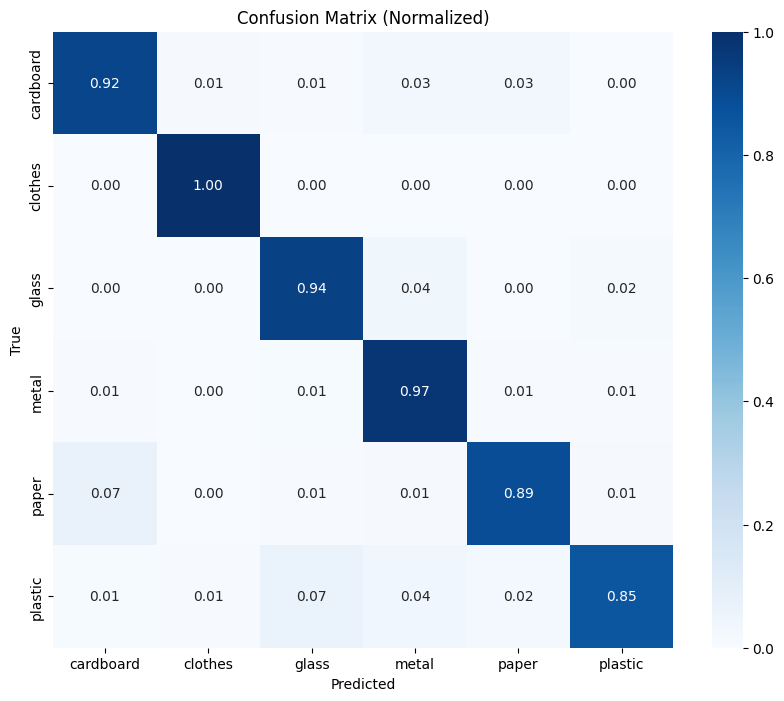

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()


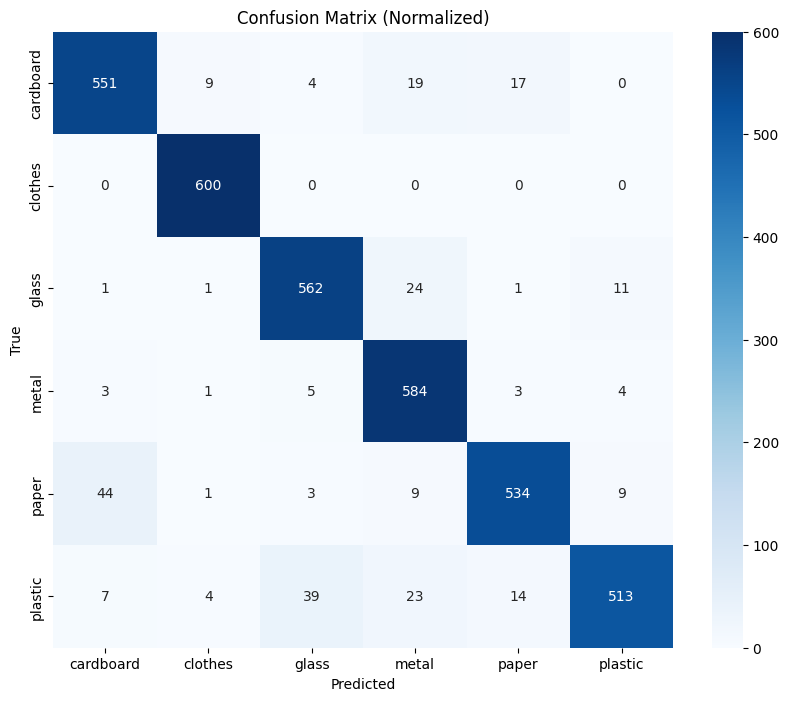

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)


plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()


In [17]:
from sklearn.metrics import classification_report

print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


📊 Classification Report:

              precision    recall  f1-score   support

   cardboard       0.91      0.92      0.91       600
     clothes       0.97      1.00      0.99       600
       glass       0.92      0.94      0.93       600
       metal       0.89      0.97      0.93       600
       paper       0.94      0.89      0.91       600
     plastic       0.96      0.85      0.90       600

    accuracy                           0.93      3600
   macro avg       0.93      0.93      0.93      3600
weighted avg       0.93      0.93      0.93      3600



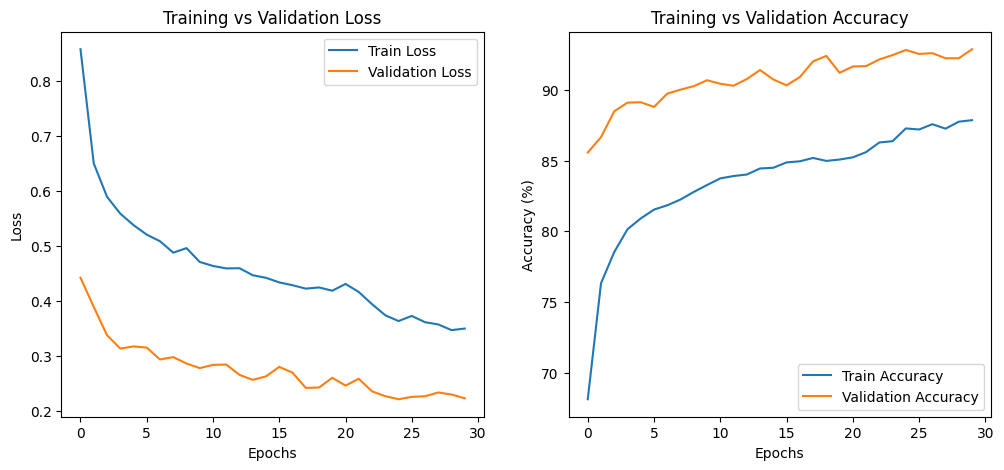

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()


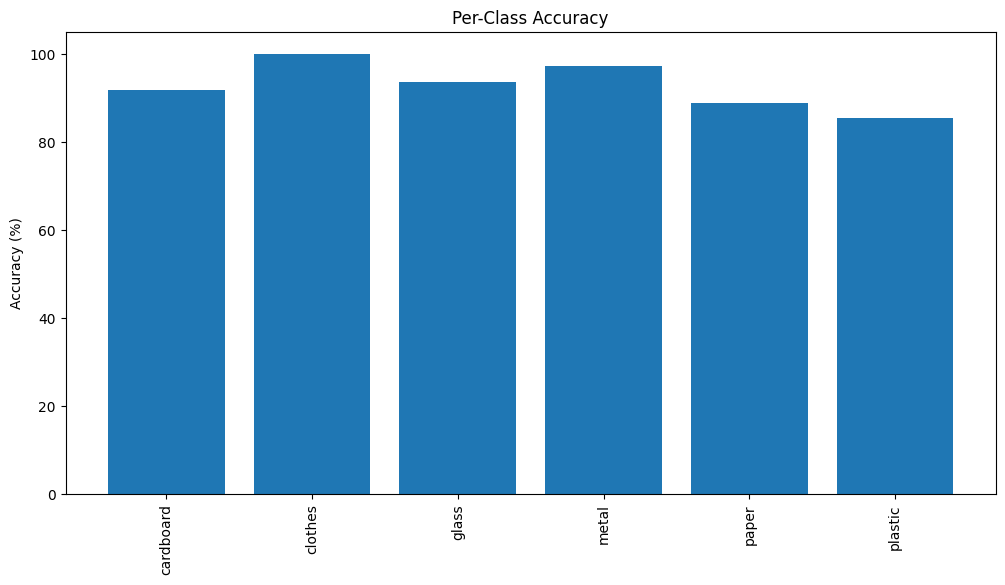

In [ ]:
import torch
import numpy as np

class_correct = [0.] * len(class_names)
class_total = [0.] * len(class_names)

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        c = (preds == labels).squeeze()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

plt.figure(figsize=(12,6))
acc_per_class = [100 * class_correct[i] / class_total[i] for i in range(len(class_names))]
plt.bar(class_names, acc_per_class)
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.show()


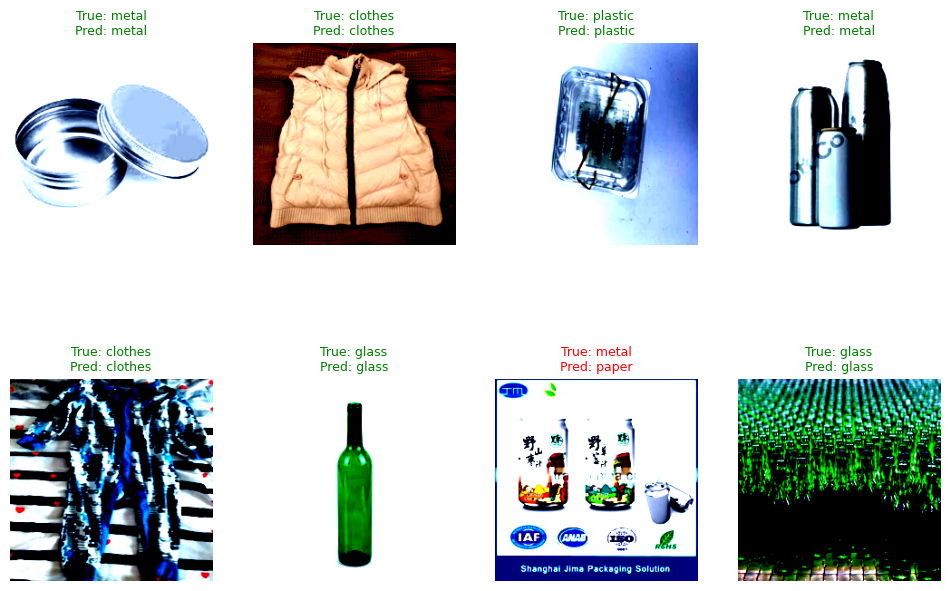

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

model.eval()
inputs, labels = next(iter(val_loader))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,8))
for i in range(8): 
    ax = plt.subplot(2,4,i+1)
    imshow(inputs[i])
    ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}",
                 fontsize=9, color=("green" if preds[i]==labels[i] else "red"))
plt.show()


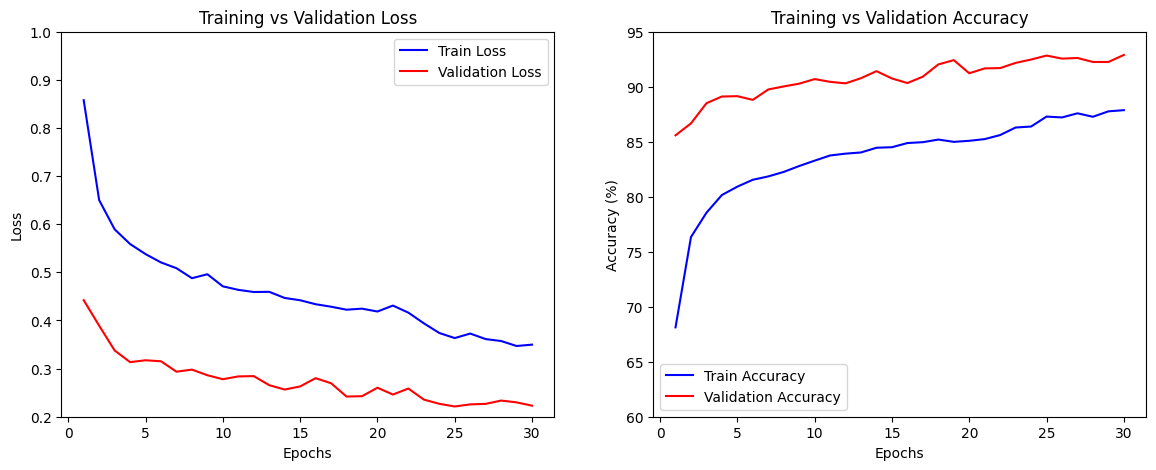

In [ ]:
import matplotlib.pyplot as plt



epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss", color="blue")
plt.plot(epochs, val_losses, label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.ylim(0.2, 1.0)  

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy", color="blue")
plt.plot(epochs, val_accuracies, label="Validation Accuracy", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.ylim(60, 95)  

plt.show()


In [ ]:
def predict_image_with_recycling(image_path):
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)
    
    predicted_class = class_names[predicted.item()]
    recycle_info = recycling_guide[predicted_class]
    
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"Predicted: {predicted_class}", fontsize=14, weight="bold")
    
    ax.text(0.5, -0.1, recycle_info["method"], ha="center", fontsize=12, weight="bold", color="green", transform=ax.transAxes)
    ax.text(0.5, -0.22, recycle_info["process"], ha="center", fontsize=9, style="italic", wrap=True, transform=ax.transAxes)
    
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    return predicted_class, recycle_info


In [64]:
recycling_guide = {
    "cardboard": {
        "method": "📦 Shredding & pulping to make new paper products.",
        "process": "Flatten the cardboard, keep it dry, and place it in the recycling bin. Avoid greasy or wet cardboard."
    },
    "clothes": {
        "method": "👕 Fiber recovery for new textiles or insulation materials.",
        "process": "Donate if wearable. Otherwise, take to textile recycling centers. Avoid putting in general waste bins."
    },
    "glass": {
        "method": "🍾 Melting & remolding into new glass products.",
        "process": "Rinse bottles/jars and remove lids. Place in glass recycling bin. Avoid mixing broken glass with regular recyclables."
    },
    "metal": {
        "method": "⚙️ Melting & reshaping into new metal items.",
        "process": "Rinse cans, tins, and foil. Place them in metal recycling. Large metal items should go to scrap yards."
    },
    "paper": {
        "method": "📄 Pulping & remanufacturing into recycled paper products.",
        "process": "Keep paper dry and clean. Recycle newspapers, magazines, and office paper. Avoid greasy or plastic-coated paper."
    },
    "plastic": {
        "method": "🛍 Shredding, melting & remolding into new plastic products.",
        "process": "Check recycling codes. Clean bottles/containers before recycling. Some plastics may need to go to special recycling centers."
    }
}


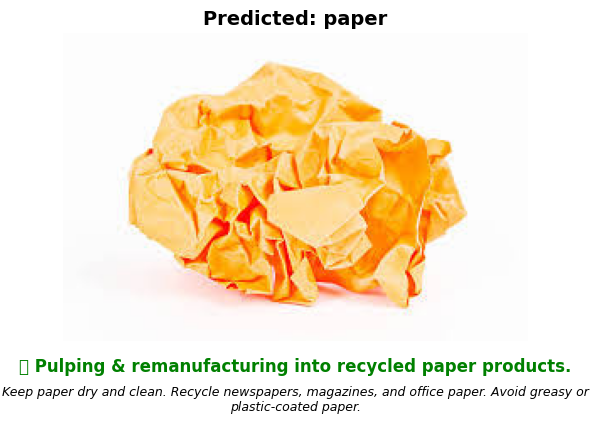

In [88]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (1).jpg")


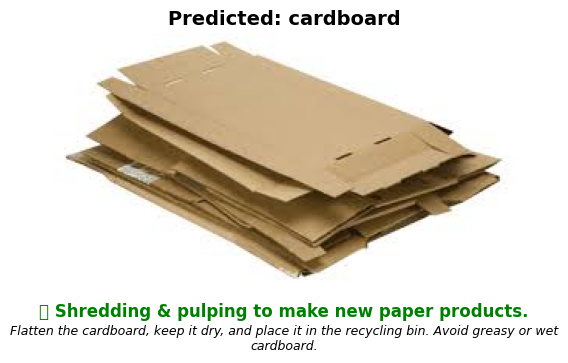

In [89]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (2).jpg")


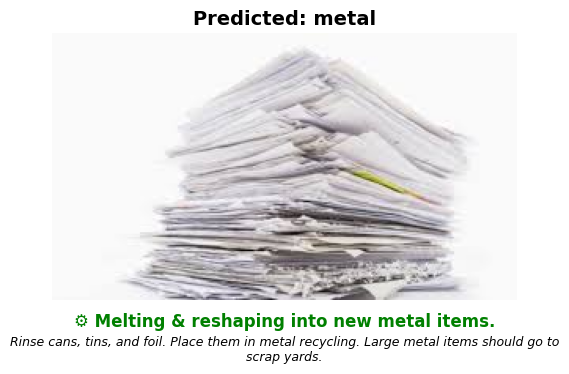

In [90]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (3).jpg")


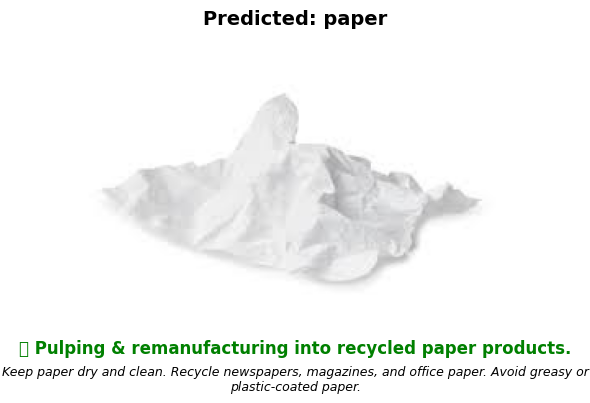

In [91]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (4).jpg")


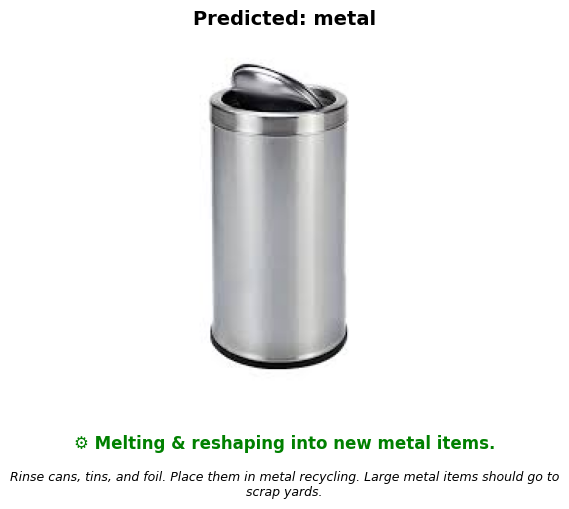

In [93]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (5).jpg")


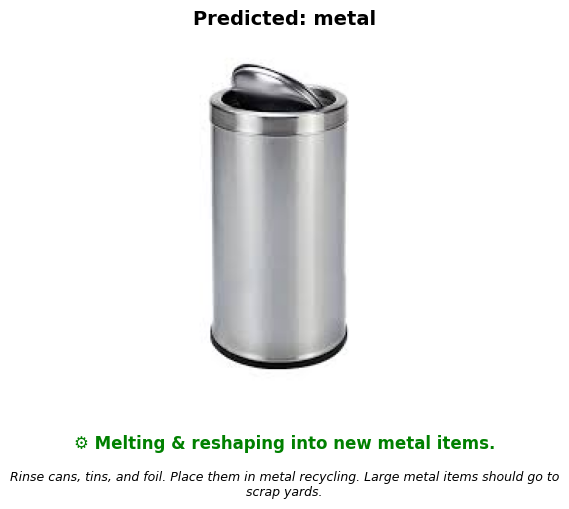

In [94]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (5).jpg")


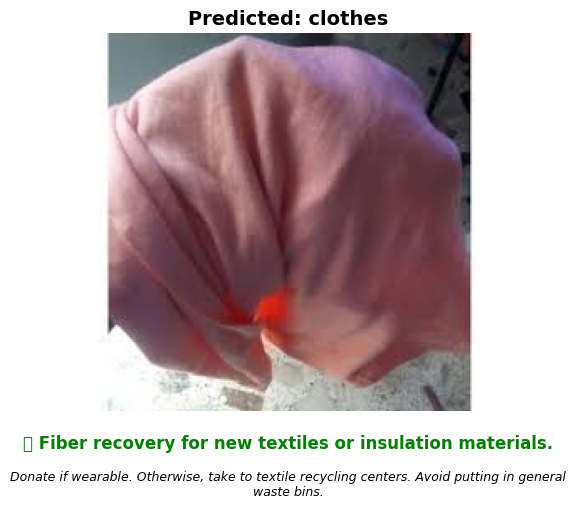

In [95]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (10).jpg")


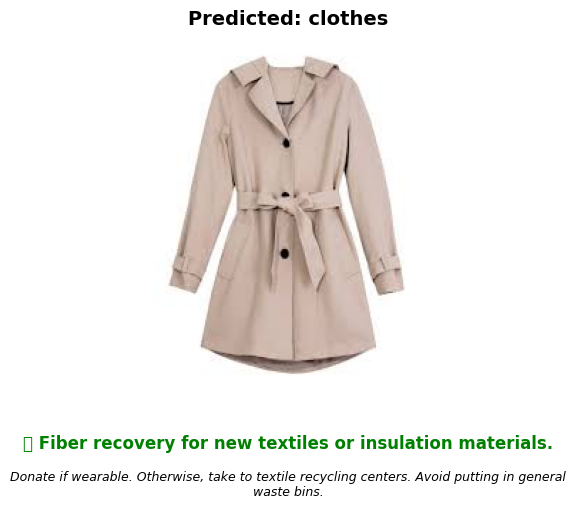

In [96]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (13).jpg")


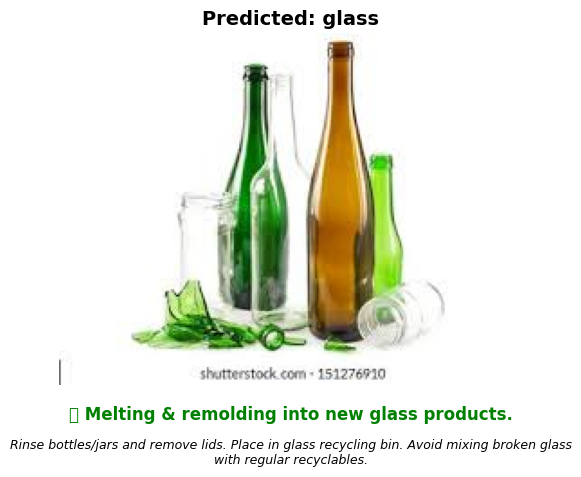

In [97]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (15).jpg")


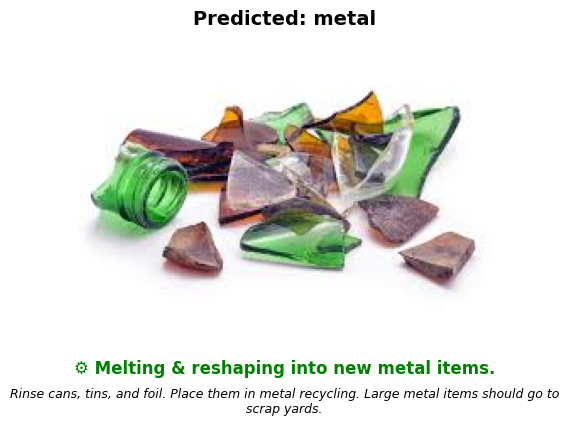

In [98]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (17).jpg")


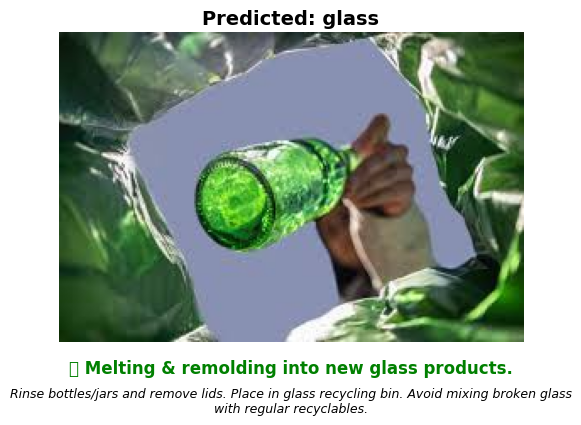

In [99]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (16).jpg")


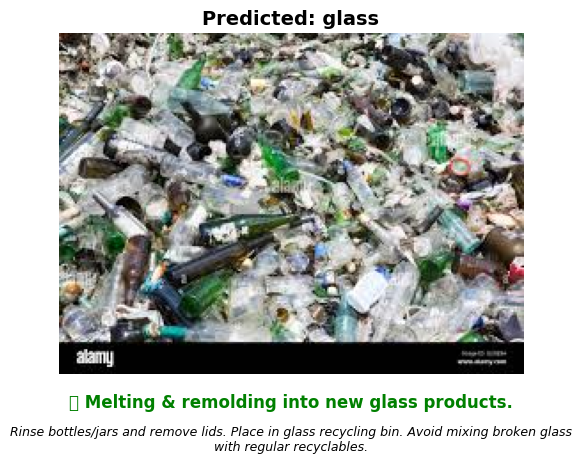

In [103]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/download (19).jpg")


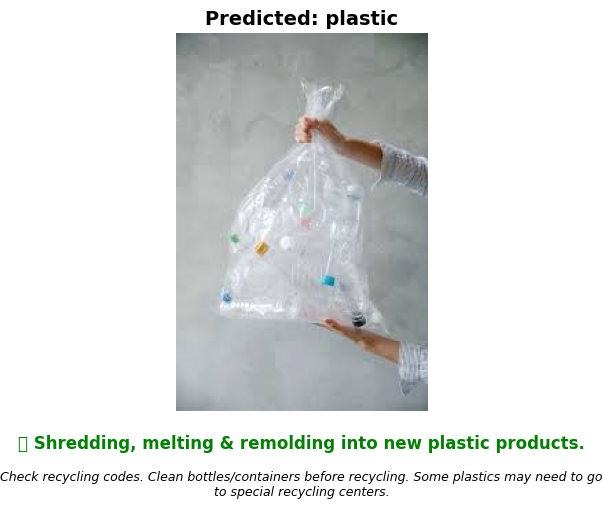

In [106]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/images (5).jpg")


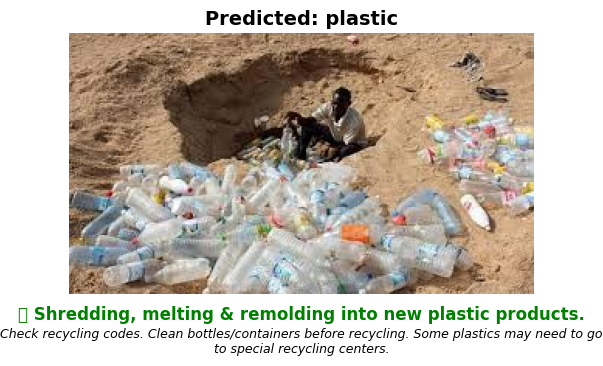

In [107]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/images (7).jpg")


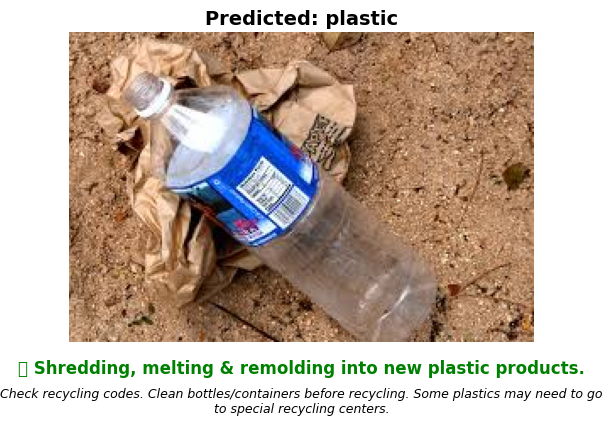

In [110]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/images (3).jpg")


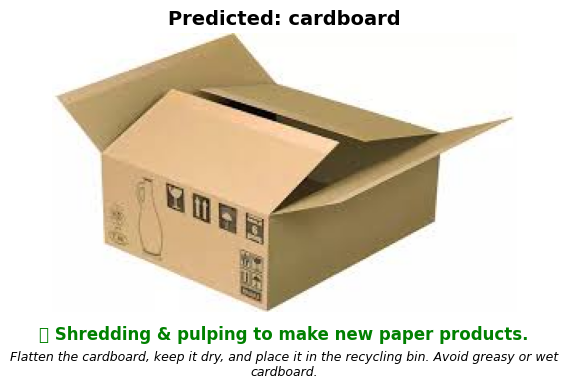

In [111]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/images.jpg")


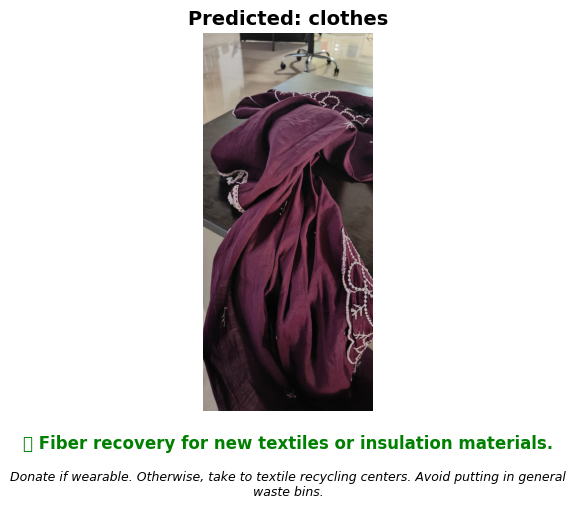

In [113]:
predicted_class, recycle_info = predict_image_with_recycling("/kaggle/input/waste-images1/example1.jpg")
